In [141]:
from pydmd import DMD
import numpy as np
from skimage import io
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
from pydmd import BOPDMD


In [148]:
#movie = io.imread("D:\data\LEXY\simLEXY\simLEXY_data_100cells10frames.tif")
movie = io.imread("D:\data\LEXY\simLEXY\cell4.tif")
#movie = movie[0]

height, width = movie.shape[1:]
n_frames = movie.shape[0]

movie = movie - movie.mean()
X = movie.reshape(movie.shape[0], -1).T
T = np.linspace(0, n_frames, n_frames)

In [149]:
n_modes = 4
dmd = BOPDMD(svd_rank=n_modes)
dmd.fit(X, T)

C:\Users\stealth\anaconda3\envs\torch_env\Lib\site-packages\pydmd\bopdmd.py:973: UserWarning: Initial trial of Optimized DMD failed to converge. Consider re-adjusting your variable projection parameters with the varpro_opts_dict and consider setting verbose=True.
  warnings.warn(msg)


(232656, 4)
(4, 26)


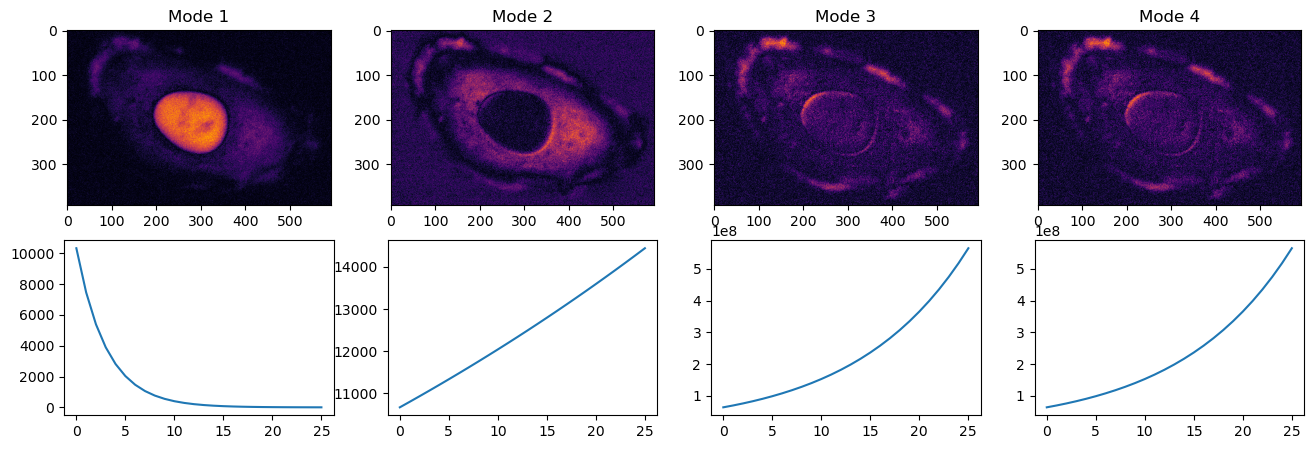

In [150]:
print(dmd.modes.shape)
print(dmd.dynamics.shape)

#fig, axs = plt.subplots(2, n_modes, figsize=(16, 5), sharex=True, sharey=True)
fig, axs = plt.subplots(2, n_modes, figsize=(16, 5))
for i in range(n_modes):
    image = np.abs(dmd.modes[:, i]).reshape(movie.shape[1:])
    axs[0, i].imshow(image, cmap='inferno')
    axs[0, i].set_title(f"Mode {i+1}")

    axs[1, i].plot(dmd.dynamics[i].real)



In [151]:
movie_rec = dmd.reconstructed_data.real.reshape(height, width, n_frames).transpose(2,0,1)

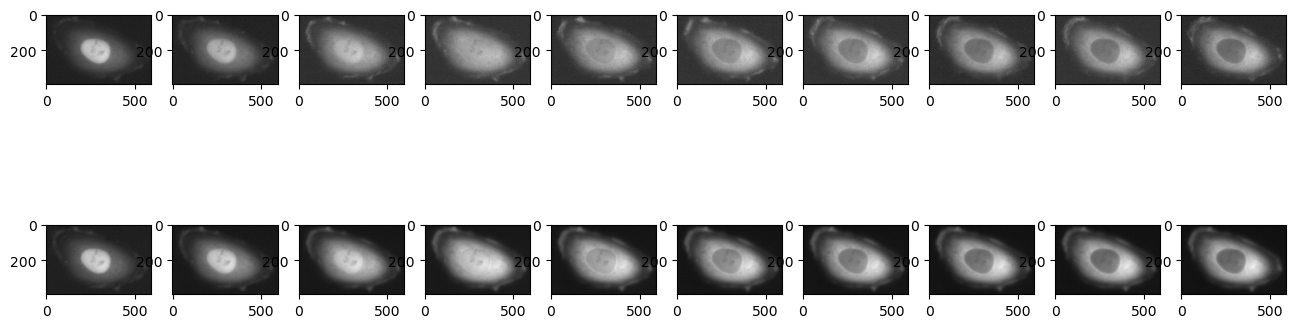

In [152]:
fig, axs = plt.subplots(2, 10, figsize=(16, 5))
for i in range(10):
    axs[0, i].imshow(movie[i], cmap='gray')
    axs[1, i].imshow(movie_rec[i], cmap='gray')


In [153]:
fig, ax = plt.subplots(1,2, figsize=(8,4))
print(n_frames)

im1 = ax[0].imshow(movie[0], cmap="gray")
im2 = ax[1].imshow(movie_rec[0], cmap="gray")

ax[0].set_title("Original")
ax[1].set_title("Reconstruction")

for a in ax:
    a.axis("off")

def update(i):
    im1.set_data(movie[i])
    im2.set_data(movie_rec[i])
    return im1, im2

ani = FuncAnimation(
    fig,
    update,
    frames=n_frames,
    interval=100,
    blit=True
)

plt.close(fig)
HTML(ani.to_jshtml())

26


In [134]:
movie_rec = np.real(movie_rec)
n_frames, H, W = movie_rec.shape

fig, ax = plt.subplots(figsize=(5,5))

im = ax.imshow(movie_rec[0], cmap="gray")
ax.axis("off")

# fix intensity range for consistent contrast
vmin = movie_rec.min()
vmax = movie_rec.max()
im.set_clim(vmin, vmax)

def update(frame):
    im.set_data(movie_rec[frame])
    ax.set_title(f"Frame {frame}")
    return [im]

ani = FuncAnimation(
    fig,
    update,
    frames=n_frames,
    interval=50,   # milliseconds between frames
    blit=True
)

plt.close(fig)  # avoid showing the static image

HTML(ani.to_jshtml())